In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("Threats (1).csv")
data = data.drop(columns = ["Unnamed: 0","id"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135341 entries, 0 to 135340
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                135341 non-null  float64
 1   proto              135341 non-null  object 
 2   service            135341 non-null  object 
 3   state              135341 non-null  object 
 4   spkts              135341 non-null  int64  
 5   dpkts              135341 non-null  int64  
 6   sbytes             135341 non-null  int64  
 7   dbytes             135341 non-null  int64  
 8   rate               135341 non-null  float64
 9   sttl               135341 non-null  int64  
 10  dttl               135341 non-null  int64  
 11  sload              135341 non-null  float64
 12  dload              135341 non-null  float64
 13  sloss              135341 non-null  int64  
 14  dloss              135341 non-null  int64  
 15  sinpkt             135341 non-null  float64
 16  di

In [3]:
data

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.012996,tcp,-,FIN,16,18,1540,1644,2539.242797,31,...,1,6,0,0,0,5,7,0,Normal,0
1,0.004119,tcp,-,FIN,12,12,1064,2260,5583.879675,31,...,1,1,0,0,0,3,8,0,Normal,0
2,0.000988,udp,dns,CON,2,2,146,178,3036.437382,31,...,1,2,0,0,0,7,2,0,Normal,0
3,3.415787,tcp,ssh,FIN,230,238,24344,29556,136.718127,31,...,1,1,0,0,0,4,1,0,Normal,0
4,0.193943,tcp,-,FIN,72,74,4238,63618,747.642372,31,...,1,5,0,0,0,6,12,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135336,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
135337,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,...,1,2,0,0,0,1,1,0,Shellcode,1
135338,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
135339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1


In [4]:
data.head()

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.012996,tcp,-,FIN,16,18,1540,1644,2539.242797,31,...,1,6,0,0,0,5,7,0,Normal,0
1,0.004119,tcp,-,FIN,12,12,1064,2260,5583.879675,31,...,1,1,0,0,0,3,8,0,Normal,0
2,0.000988,udp,dns,CON,2,2,146,178,3036.437382,31,...,1,2,0,0,0,7,2,0,Normal,0
3,3.415787,tcp,ssh,FIN,230,238,24344,29556,136.718127,31,...,1,1,0,0,0,4,1,0,Normal,0
4,0.193943,tcp,-,FIN,72,74,4238,63618,747.642372,31,...,1,5,0,0,0,6,12,0,Normal,0


In [5]:
data

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.012996,tcp,-,FIN,16,18,1540,1644,2539.242797,31,...,1,6,0,0,0,5,7,0,Normal,0
1,0.004119,tcp,-,FIN,12,12,1064,2260,5583.879675,31,...,1,1,0,0,0,3,8,0,Normal,0
2,0.000988,udp,dns,CON,2,2,146,178,3036.437382,31,...,1,2,0,0,0,7,2,0,Normal,0
3,3.415787,tcp,ssh,FIN,230,238,24344,29556,136.718127,31,...,1,1,0,0,0,4,1,0,Normal,0
4,0.193943,tcp,-,FIN,72,74,4238,63618,747.642372,31,...,1,5,0,0,0,6,12,0,Normal,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
135336,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,13,24,0,0,0,24,24,0,Generic,1
135337,0.505762,tcp,-,FIN,10,8,620,354,33.612649,254,...,1,2,0,0,0,1,1,0,Shellcode,1
135338,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,3,13,0,0,0,3,12,0,Generic,1
135339,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,...,14,30,0,0,0,30,30,0,Generic,1


## using label encoding for proto, service, state and attack_cat

In [6]:
def label_encoding(name):
    uni = data[f"{name}"].unique()
    l = [i for i in range(len(uni))]
    dic = dict(zip(uni,l))
    data[f"{name}"] = data[f"{name}"].map(dic)
    
label_encoding("proto")
label_encoding("service")
label_encoding("state")
label_encoding("attack_cat")
data = data.astype(float)

In [7]:
data["attack_cat"].unique()

array([0., 1., 2., 3., 4., 5., 6., 7., 8., 9.])

In [8]:
target = data["attack_cat"]
data = data.drop(columns = ["attack_cat"])

In [9]:
corr = data.corr()

In [10]:
def correlation_check(i,j):
    return data[[i, j]].corr().iloc[0, 1]

## dropping features having correlation more than .70

In [11]:
columns = list(data.columns)
for i in columns:
    for j in columns:
        cor_value = correlation_check(i,j)
        if cor_value == 1:
            continue
                
        elif abs(cor_value) >= .8:
            if j in columns:
                data = data.drop(columns = [j])
                columns.remove(j)
                print(f"Correlation between {i} and {j}: {cor_value}")
                print(f"droppped {j}")
            else:
                continue     
        else:
            continue

Correlation between state and dttl: -0.9777773114676039
droppped dttl
Correlation between state and swin: -0.9564073287283896
droppped swin
Correlation between state and dwin: -0.9826874356801958
droppped dwin
Correlation between spkts and sbytes: 0.991083640311391
droppped sbytes
Correlation between spkts and sloss: 0.9912988088546151
droppped sloss
Correlation between dpkts and dbytes: 0.9730097083383443
droppped dbytes
Correlation between dpkts and dloss: 0.9731621314901971
droppped dloss
Correlation between sinpkt and is_sm_ips_ports: 0.9452100690517068
droppped is_sm_ips_ports
Correlation between dinpkt and sjit: 0.9230107916750923
droppped sjit
Correlation between tcprtt and synack: 0.9460894740332736
droppped synack
Correlation between ackdat and tcprtt: 0.9375167281909091
droppped tcprtt
Correlation between ct_srv_src and ct_dst_ltm: 0.857573491685824
droppped ct_dst_ltm
Correlation between ct_srv_src and ct_dst_sport_ltm: 0.8413544578735964
droppped ct_dst_sport_ltm
Correlatio

In [12]:
data = data.drop(columns = ["ct_ftp_cmd"])

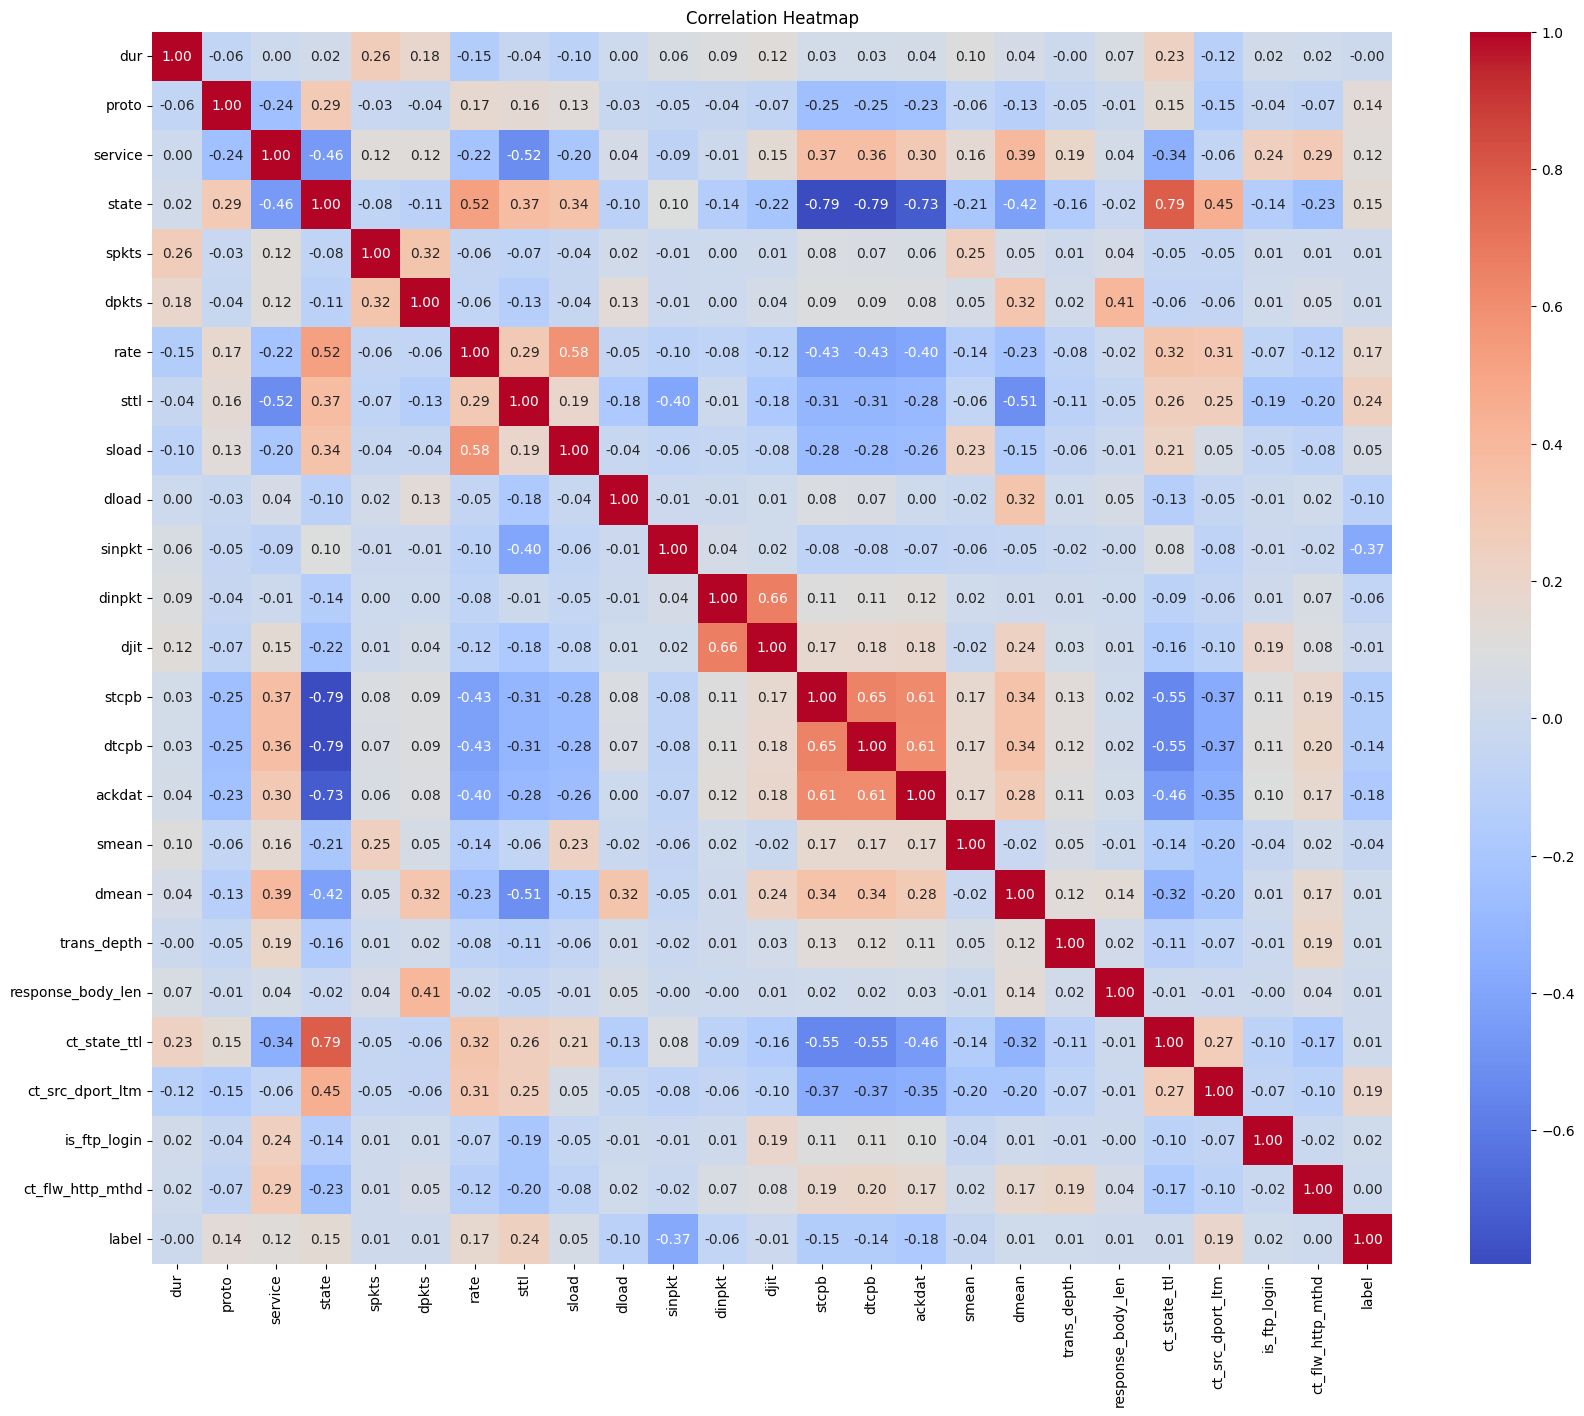

In [13]:
corr = data.corr()
plt.figure(figsize = (20,16))
sns.heatmap(corr, cmap = "coolwarm", annot= True, fmt = ".2f")
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap")
plt.show()

In [14]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth= 10) 

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data, target, test_size=.3, random_state=42)

In [16]:
model.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=10)

In [17]:
Y_pred = model.predict(X_test)

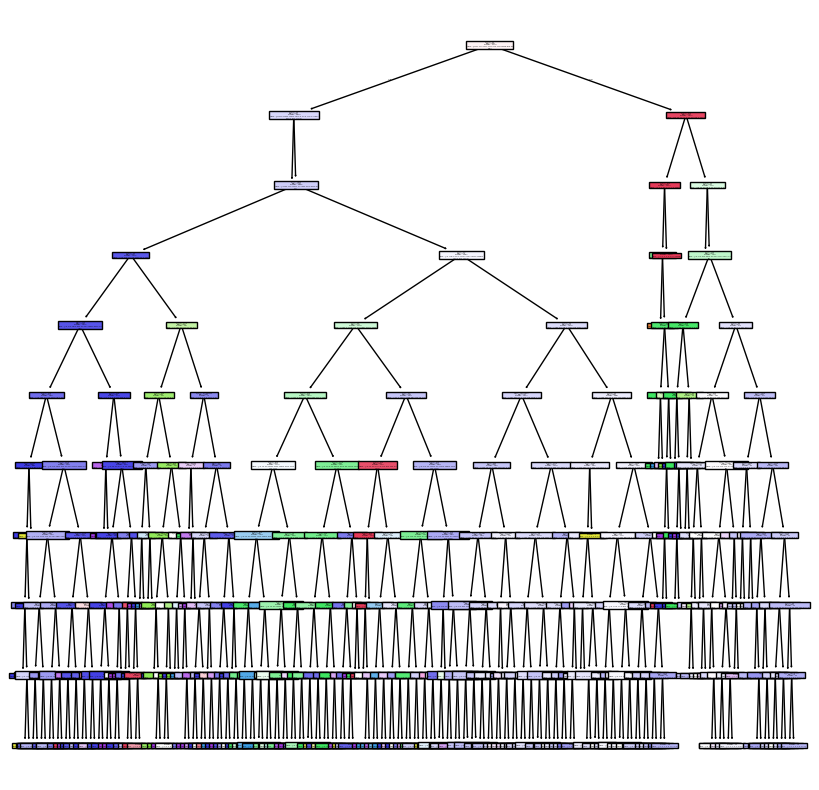

In [18]:
from sklearn import tree
plt.figure(figsize = (10, 10))
tree.plot_tree(model, filled = True)
plt.show()

## accuracy in testing data

In [19]:
from sklearn.metrics import accuracy_score,f1_score
accuracy = accuracy_score(Y_test, Y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.81


## Accuracy in traning data

In [22]:
Y_pre = model.predict(X_train)
plt.figure(figsize = (10, 10))
tree.plot_tree(model, filled = True)
plt.show()
accuracy = accuracy_score(Y_train, Y_pre)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.82
